# XAI vs No XAI Comparison - IC50 MPro Task

Comparing the effect of explainable AI (XAI) guidance on molecule optimization performance for IC50 prediction against SARS-CoV-2 Main Protease (MPro).

**Note**: For IC50, lower values are better. Only molecules with QED ≥ 0.6 are considered valid; molecules below this threshold are assigned a penalty score.


In [10]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random 

random.seed(42)
np.random.seed(42)


In [11]:
# Define paths
RESULTS_DIR = Path("../../data/results/ic50mpro_qed")

# Penalty value for molecules with QED < 0.6 (in nM)
# Using 1,000,000 nM (1 mM) as a high but finite penalty
QED_PENALTY_IC50 = 1_000_000
QED_THRESHOLD = 0.6

# Define experiment groups: (display_name, folder_name)
GROUPS = [
    ("Claude Opus 4.5 (Full XAI)", "claude-opus-4.5_full_xai"),
    ("Claude Opus 4.5 (Partial XAI)", "claude-opus-4.5_partial_xai"),
    ("Claude Opus 4.5 (No XAI)", "claude-opus-4.5_no_xai"),
    ("Claude Opus 4.5 (No description)", "claude-opus-4.5_no_description"),
]


## Loading Data


In [12]:
def load_trace(p: Path) -> list:
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d


def load_results_as_df(results_dir: Path, groups: list, qed_threshold: float, penalty: float) -> pd.DataFrame:
    """Load all results from JSON trace files into a DataFrame.
    
    For molecules with QED < qed_threshold, the IC50 score is replaced with a penalty value.
    
    Returns DataFrame with columns: model, replicate, iteration, score, effective_score, qed, smiles
    """
    rows = []
    
    for display_name, folder_name in groups:
        folder_path = results_dir / folder_name
        files = sorted(folder_path.glob("ic50mpro_qed_*.json"))
        
        if not files:
            print(f"Warning: No files in {folder_path} matching ic50mpro_qed_*.json")
            continue
        
        for file_path in files:
            # Extract replicate number from filename (e.g., "rep1", "rep2")
            rep_match = re.search(r'rep(\d+)', file_path.name)
            replicate = int(rep_match.group(1)) if rep_match else 0
            
            try:
                trace = load_trace(file_path)
                for entry in trace:
                    ic50_score = float(entry["score"])
                    qed = float(entry["scores"]["QED"])
                    
                    # Apply penalty for molecules with QED below threshold
                    effective_score = ic50_score if qed >= qed_threshold else penalty
                    
                    rows.append({
                        "model": display_name,
                        "replicate": replicate,
                        "iteration": int(entry["iteration"]),
                        "score": ic50_score,
                        "effective_score": effective_score,
                        "qed": qed,
                        "smiles": entry["smiles"],
                    })
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    return pd.DataFrame(rows)


# Load all results
df = load_results_as_df(RESULTS_DIR, GROUPS, QED_THRESHOLD, QED_PENALTY_IC50)


In [13]:
# Check QED distribution and how many molecules pass the threshold
qed_stats = df.groupby('model').agg(
    total_molecules=('qed', 'count'),
    qed_above_threshold=('qed', lambda x: (x >= QED_THRESHOLD).sum()),
    qed_below_threshold=('qed', lambda x: (x < QED_THRESHOLD).sum()),
    mean_qed=('qed', 'mean'),
).round(3)
qed_stats['pct_valid'] = (qed_stats['qed_above_threshold'] / qed_stats['total_molecules'] * 100).round(1)
print(f"QED threshold: {QED_THRESHOLD}")
qed_stats


QED threshold: 0.6


,total_molecules,qed_above_threshold,qed_below_threshold,mean_qed,pct_valid
model,,,,,
Claude Opus 4.5 (Full XAI),147,132,15,0.750,89.8
Claude Opus 4.5 (No XAI),150,104,46,0.658,69.3
Claude Opus 4.5 (No description),149,55,94,0.571,36.9
Claude Opus 4.5 (Partial XAI),150,137,13,0.760,91.3


In [14]:
# Check for runs with fewer than expected iterations
run_lengths = df.groupby(['model', 'replicate'])['iteration'].max()
expected_iterations = run_lengths.max()
short_runs = run_lengths[run_lengths < expected_iterations]

print(f"Expected iterations: {expected_iterations}")
if len(short_runs) > 0:
    print(f"\nFound {len(short_runs)} runs with fewer than {expected_iterations} iterations:")
    print(short_runs.sort_values())
else:
    print(f"All runs have {expected_iterations} iterations")


Expected iterations: 50
All runs have 50 iterations


---
## Best-so-far Progression Plot

For IC50 (lower is better), we use cumulative minimum. Molecules with QED < 0.6 are assigned a penalty score.


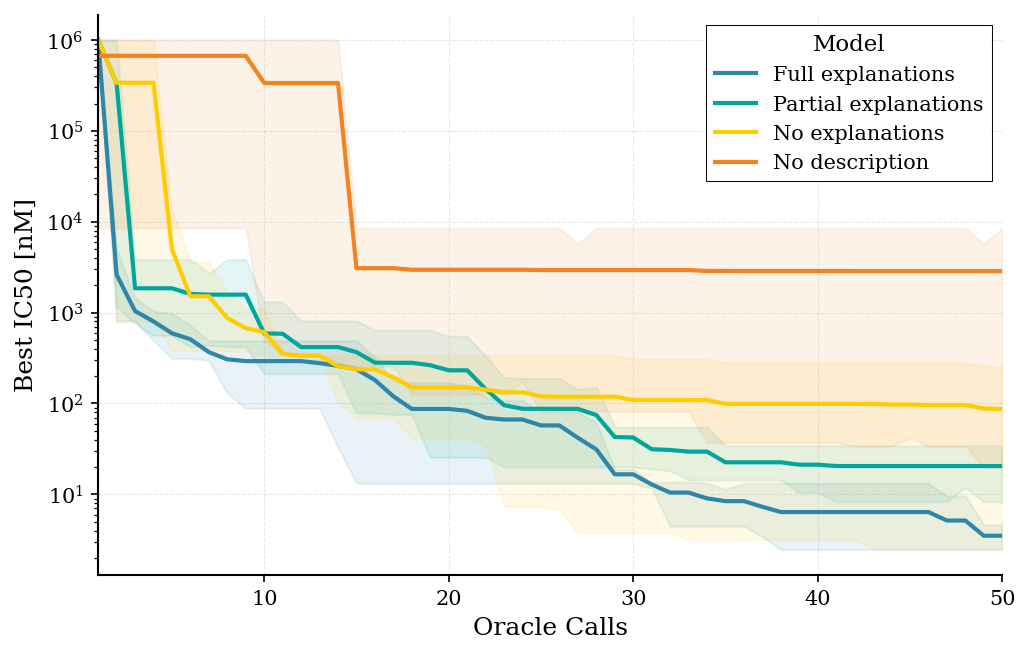

In [15]:
# Compute best-so-far using cummin (for IC50, lower is better)
# Using effective_score which has penalty applied for QED < threshold
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "replicate"])["effective_score"]
    .cummin()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "replicate"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 2.0,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# Define color palette for explanation conditions
model_colors = {
    'Claude Opus 4.5 (Full XAI)': '#2E86AB',
    'Claude Opus 4.5 (Partial XAI)': '#00a69d',
    'Claude Opus 4.5 (No XAI)': '#ffcc00',
    'Claude Opus 4.5 (No description)': '#f58220',
}

# Define legend order and labels
legend_order = [
    'Claude Opus 4.5 (Full XAI)',
    'Claude Opus 4.5 (Partial XAI)',
    'Claude Opus 4.5 (No XAI)',
    'Claude Opus 4.5 (No description)',
]

legend_labels = {
    'Claude Opus 4.5 (Full XAI)': 'Full explanations',
    'Claude Opus 4.5 (Partial XAI)': 'Partial explanations',
    'Claude Opus 4.5 (No XAI)': 'No explanations',
    'Claude Opus 4.5 (No description)': 'No description',
}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model",
    hue_order=legend_order,
    palette=model_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.0,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=12, fontweight='normal')
ax.set_ylabel("Best IC50 [nM]", fontsize=12, fontweight='normal')
ax.set_xlim(1, 50)
# Use log scale for IC50 as values can span several orders of magnitude
ax.set_yscale('log')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve legend with renamed labels
handles, labels = ax.get_legend_handles_labels()
new_labels = [legend_labels.get(label, label) for label in labels]
legend = ax.legend(
    handles,
    new_labels,
    title='Model',
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.95,
    edgecolor='black',
    loc='upper right'
)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/xai_vs_no_xai_ic50mpro.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()


---
## Iteration to Reach IC50 Threshold

Finding the first iteration where the best-so-far IC50 drops below a target threshold (only for molecules with QED ≥ 0.6).


In [16]:
# Target IC50 threshold in nM (lower is better)
IC50_THRESHOLD = 100  # nM

def first_iteration_below_threshold(group, threshold=IC50_THRESHOLD):
    """Return first iteration where best_so_far <= threshold, or NaN if never reached.
    
    For IC50, lower is better, so we check for values BELOW the threshold.
    """
    below = group[group["best_so_far"] <= threshold]
    if len(below) > 0:
        return below["iteration"].min()
    return np.nan


def bootstrap_ci(data, n_bootstrap=10000, ci=0.95):
    """Compute bootstrap 95% CI for the mean."""
    data = data.dropna()
    if len(data) < 2:
        return np.nan, np.nan
    result = stats.bootstrap(
        (data.values,), 
        statistic=np.mean, 
        n_resamples=n_bootstrap, 
        confidence_level=ci,
        random_state=42
    )
    return result.confidence_interval.low, result.confidence_interval.high


# Compute for each model and replicate
iter_to_threshold = (
    df
    .groupby(["model", "replicate"])
    .apply(first_iteration_below_threshold, include_groups=False)
    .reset_index(name="iter_to_threshold")
)

# Summarize by model with bootstrap CI
summary_rows = []
for model, group in iter_to_threshold.groupby("model"):
    values = group["iter_to_threshold"]
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    n_total = len(values)
    never_reached = values.isna().sum()
    success_rate = (n_total - never_reached) / n_total * 100
    summary_rows.append({
        "Model": model,
        "Mean Iteration": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "N": n_total,
        "Never Reached": never_reached,
        "Success Rate (%)": success_rate
    })

threshold_summary = pd.DataFrame(summary_rows).set_index("Model").round(2)

print(f"Iteration to reach IC50 ≤ {IC50_THRESHOLD} nM threshold (with QED ≥ {QED_THRESHOLD}) — 95% Bootstrap CI")
threshold_summary


Iteration to reach IC50 ≤ 100 nM threshold (with QED ≥ 0.6) — 95% Bootstrap CI


,Mean Iteration,CI 95% Low,CI 95% High,N,Never Reached,Success Rate (%)
Model,,,,,,
Claude Opus 4.5 (Full XAI),17.33,9.0,25.0,3,0,100.00
Claude Opus 4.5 (No XAI),16.50,15.0,18.0,3,1,66.67
Claude Opus 4.5 (No description),29.50,25.0,34.0,3,1,66.67
Claude Opus 4.5 (Partial XAI),22.00,15.0,29.0,3,0,100.00


---
## AUC Top-1 over 50 Iterations

For IC50 (lower is better), lower AUC indicates better performance.


In [17]:
def compute_auc_top1_ic50(group_df, max_oracle_calls=50, penalty=QED_PENALTY_IC50):
    """Compute AUC of top-1 (best) IC50 score vs oracle calls from a dataframe group.
    
    For IC50, lower is better, so we track the cumulative minimum.
    
    Args:
        group_df: DataFrame with 'effective_score' and 'iteration' columns for a single run
        max_oracle_calls: Maximum number of oracle calls (default 50)
        penalty: Starting penalty value for runs with no valid molecules yet
    
    Returns:
        AUC value (lower is better for IC50)
    """
    sorted_df = group_df.sort_values('iteration')
    
    best_score = penalty  # Start with penalty (worst case)
    best_at_call = {}
    
    for _, row in sorted_df.iterrows():
        oracle_call = int(row['iteration'])
        score = float(row['effective_score'])
        
        if oracle_call > max_oracle_calls:
            break
        
        # For IC50, lower is better
        if score < best_score:
            best_score = score
        
        best_at_call[oracle_call] = best_score
    
    if not best_at_call:
        # No data points within max_oracle_calls
        return penalty * max_oracle_calls
    
    oracle_calls = sorted(best_at_call.keys())
    
    # Compute AUC as sum of rectangles (left Riemann sum for step function)
    auc = 0.0
    prev_call = 0
    prev_best = penalty  # Start at penalty before first call
    
    for call in oracle_calls:
        auc += prev_best * (call - prev_call)
        prev_call = call
        prev_best = best_at_call[call]
    
    # Extend to max_oracle_calls
    auc += prev_best * (max_oracle_calls - prev_call)
    
    # Normalize by max_oracle_calls to get average best-so-far score
    return auc / max_oracle_calls


# Compute AUC Top-1 for each model/replicate
MAX_ORACLE_CALLS = 50

auc_records = []
for (model, replicate), group in df.groupby(['model', 'replicate']):
    auc = compute_auc_top1_ic50(group, MAX_ORACLE_CALLS)
    auc_records.append({
        'model': model,
        'replicate': replicate,
        'auc_top1': auc
    })

auc_df = pd.DataFrame(auc_records)

# Summarize by model with bootstrap CI
auc_summary_rows = []
for model, group in auc_df.groupby('model'):
    values = group['auc_top1']
    mean_val = values.mean()
    ci_low, ci_high = bootstrap_ci(values)
    # Compute distances from mean to CI bounds
    ci_low_dist = mean_val - ci_low  # Distance below mean
    ci_high_dist = ci_high - mean_val  # Distance above mean
    auc_summary_rows.append({
        "Model": model,
        "Mean AUC Top-1 (nM)": mean_val,
        "CI 95% -": ci_low_dist,
        "CI 95% +": ci_high_dist,
        "N": len(values),
    })

auc_summary = pd.DataFrame(auc_summary_rows).set_index("Model").round(1)

print(f"AUC Top-1 (IC50 in nM) over {MAX_ORACLE_CALLS} iterations — lower is better")
print(f"Penalty for QED < {QED_THRESHOLD}: {QED_PENALTY_IC50:,} nM")
print()
auc_summary


AUC Top-1 (IC50 in nM) over 50 iterations — lower is better
Penalty for QED < 0.6: 1,000,000 nM



,Mean AUC Top-1 (nM),CI 95% -,CI 95% +,N
Model,,,,
Claude Opus 4.5 (Full XAI),40187.6,12.8,11.6,3
Claude Opus 4.5 (No XAI),60610.8,20468.3,39693.5,3
Claude Opus 4.5 (No description),176184.0,147854.8,123897.4,3
Claude Opus 4.5 (Partial XAI),47067.7,6869.3,13705.9,3


---
## Final Best Scores

Best IC50 achieved by iteration 50 (only for molecules with QED ≥ 0.6).


In [18]:
# Get final best score for each run
final_scores = (
    df[df['iteration'] <= 50]
    .groupby(['model', 'replicate'])
    .agg(
        final_best_ic50=('best_so_far', 'min'),
        final_best_raw_ic50=('score', 'min'),
        best_qed=('qed', 'max'),
    )
    .reset_index()
)

# Summarize by model
final_summary_rows = []
for model, group in final_scores.groupby('model'):
    values = group['final_best_ic50']
    # For runs that never found QED >= 0.6, the value will be the penalty
    valid_runs = values[values < QED_PENALTY_IC50]
    
    mean_val = valid_runs.mean() if len(valid_runs) > 0 else np.nan
    ci_low, ci_high = bootstrap_ci(valid_runs) if len(valid_runs) >= 2 else (np.nan, np.nan)
    
    final_summary_rows.append({
        "Model": model,
        "Mean Best IC50 (nM)": mean_val,
        "CI 95% Low": ci_low,
        "CI 95% High": ci_high,
        "Min IC50 (nM)": valid_runs.min() if len(valid_runs) > 0 else np.nan,
        "N Valid Runs": len(valid_runs),
        "N Total Runs": len(group),
    })

final_summary = pd.DataFrame(final_summary_rows).set_index("Model").round(2)

print(f"Final best IC50 at iteration 50 (for molecules with QED ≥ {QED_THRESHOLD}) — lower is better")
final_summary


Final best IC50 at iteration 50 (for molecules with QED ≥ 0.6) — lower is better


,Mean Best IC50 (nM),CI 95% Low,CI 95% High,Min IC50 (nM),N Valid Runs,N Total Runs
Model,,,,,,
Claude Opus 4.5 (Full XAI),3.51,2.47,4.62,2.47,3,3
Claude Opus 4.5 (No XAI),87.05,3.29,253.84,2.56,3,3
Claude Opus 4.5 (No description),2859.01,32.51,8499.22,19.70,3,3
Claude Opus 4.5 (Partial XAI),20.49,8.28,34.24,8.28,3,3
